In [138]:
import os
import numpy as np
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import pandas as pd

In [139]:
PROMETHEUS_URL = "http://178.104.73.186:9090"
START_MINUS_MINUTES = 0
TIME_WINDOW_MINUTES = 19  # 40
END = datetime.now(timezone.utc) - timedelta(minutes=START_MINUS_MINUTES)
START = END - timedelta(minutes=TIME_WINDOW_MINUTES)
STEP = '5s'

In [140]:
vm_cpu_pct = prom_query_range(
    '100 * (1 - avg(rate(node_cpu_seconds_total{job="chat-monolith-node",mode="idle"}[1m])))',
    START, END, STEP, base_url=PROMETHEUS_URL
)
vm_cpu_pct

,series_0 {}
2026-05-13 09:34:01.630000114+00:00,22.788
2026-05-13 09:34:06.630000114+00:00,22.756
2026-05-13 09:34:11.630000114+00:00,22.708
2026-05-13 09:34:16.630000114+00:00,22.584
2026-05-13 09:34:21.630000114+00:00,22.610
...,...
2026-05-13 09:52:41.630000114+00:00,26.334
2026-05-13 09:52:46.630000114+00:00,24.144
2026-05-13 09:52:51.630000114+00:00,19.074
2026-05-13 09:52:56.630000114+00:00,16.964


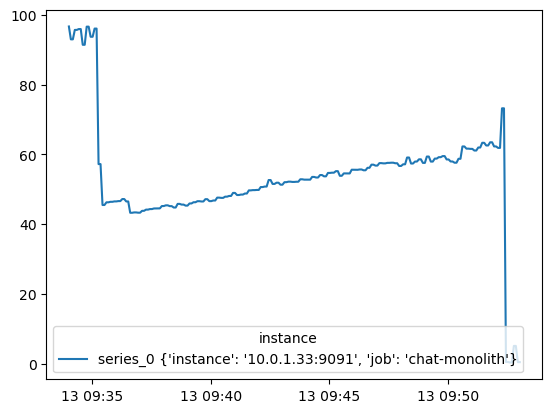

In [141]:
java_cpu_pct = prom_query_range(
    f'100 * process_cpu_usage',
    START, END, STEP, base_url=PROMETHEUS_URL
)
for col in java_cpu_pct.columns:
    plt.plot(java_cpu_pct.index, java_cpu_pct[col], label=col)
plt.legend(title="instance")
plt.show()

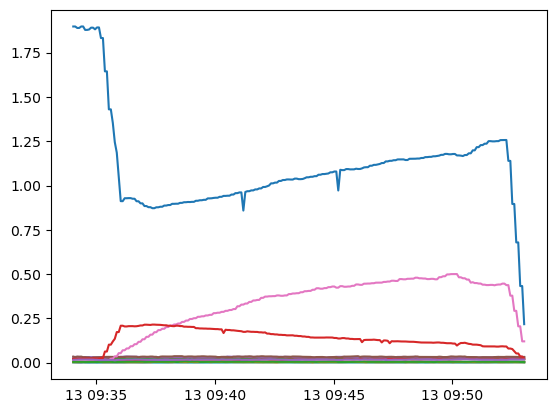

In [142]:
cpu_by_svc = prom_query_range(
    """sum by (container_label_com_docker_swarm_task_name) (
          rate(container_cpu_usage_seconds_total{
            id!="/",
            container_label_com_docker_swarm_service_name!=""
          }[1m])
        )""",
    START, END, STEP, base_url=PROMETHEUS_URL,
)

for col in cpu_by_svc.columns:
    plt.plot(cpu_by_svc.index, cpu_by_svc[col], label=str(col))
# plt.legend(title="instance")
plt.show()

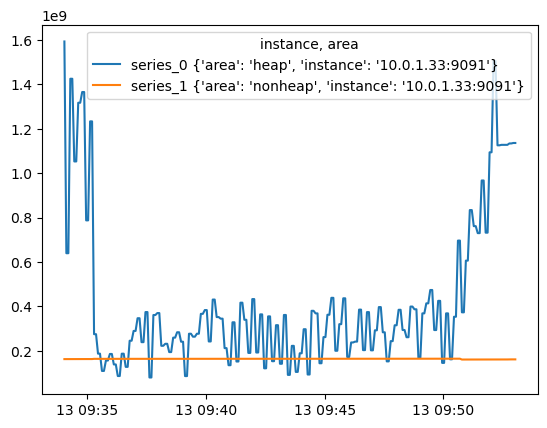

In [143]:
java_mem = prom_query_range(
    'sum by (instance, area) (jvm_memory_used_bytes{area=~"heap|nonheap"})',
    START, END, STEP, base_url=PROMETHEUS_URL
)

for col in java_mem.columns:
    plt.plot(java_mem.index, java_mem[col], label=str(col))

# todo the legend is very big so I might not display it
plt.legend(title="instance, area")
plt.show()

/var/folders/h_/g_jb8h7n13lfcr4gg3hsn8340000gn/T/ipykernel_98569/3587986393.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


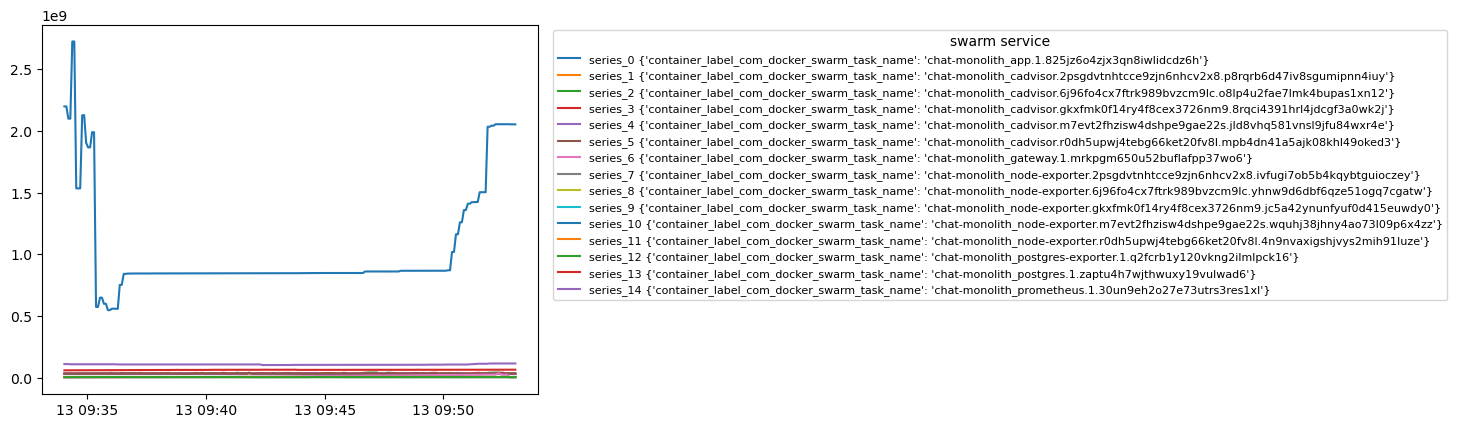

In [144]:
mem_by_svc = prom_query_range(
    """sum by (container_label_com_docker_swarm_task_name) (
        container_memory_working_set_bytes{
            id!="/",
            container_label_com_docker_swarm_service_name!=""
        }
    )""",
    START, END, STEP, base_url=PROMETHEUS_URL,
)

for col in mem_by_svc.columns:
    plt.plot(mem_by_svc.index, mem_by_svc[col], label=str(col))
plt.legend(title="swarm service", fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

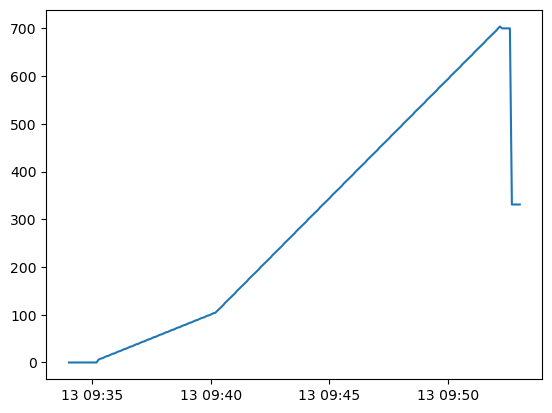

In [145]:
k6_users = prom_query_range(
    'sum(k6_vus)',
    START, END, STEP, base_url=PROMETHEUS_URL
)
plt.plot(k6_users)
plt.show()

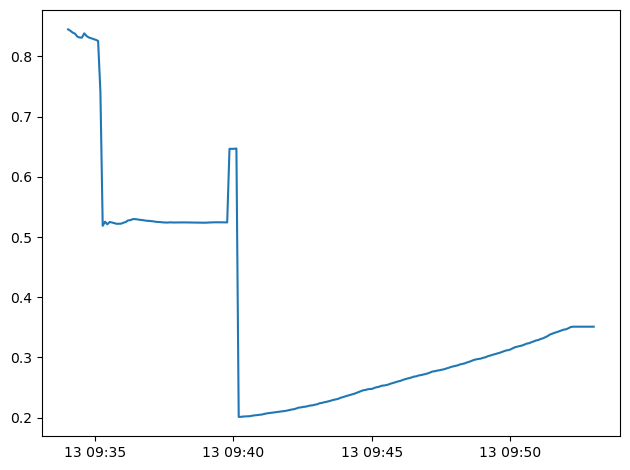

In [146]:
# Try strict HTTP latency query first, then fall back to a broader one if labels differ.
http_rt_latency = prom_query_range(
    'avg(k6_http_req_duration_p95{expected_response="true", method="GET"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)

if http_rt_latency.empty:
    http_rt_latency = prom_query_range(
        'avg(k6_http_req_duration_p95)',
        START,
        END,
        STEP,
        base_url=PROMETHEUS_URL,
    )

for col in http_rt_latency.columns:
    plt.plot(http_rt_latency.index, http_rt_latency[col], label=str(col))
plt.tight_layout()
plt.show()

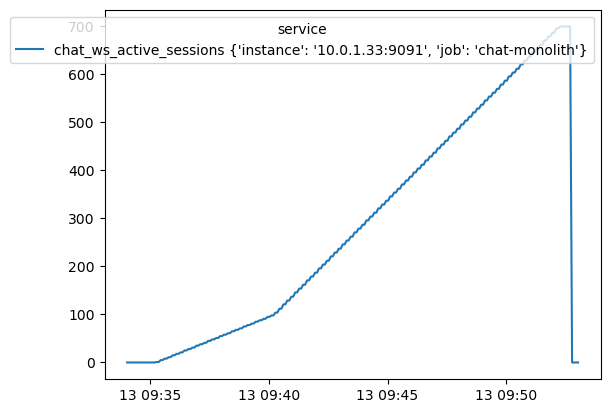

In [147]:
ws_active_sessions = prom_query_range(
    f'chat_ws_active_sessions',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)

for col in ws_active_sessions.columns:
    plt.plot(ws_active_sessions.index, ws_active_sessions[col], label=str(col))
plt.legend(title="service")
plt.show()

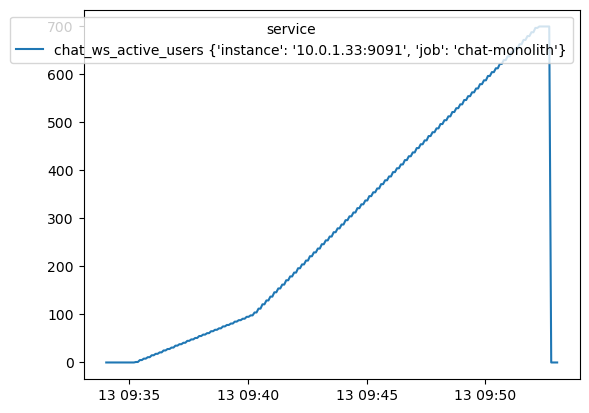

In [148]:
ws_users = prom_query_range(
    f'chat_ws_active_users',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
for col in ws_users.columns:
    plt.plot(ws_users.index, ws_users[col], label=str(col))
plt.legend(title="service")
plt.show()

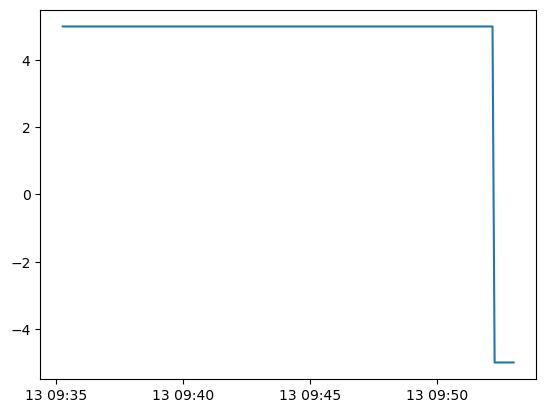

In [149]:
vus_http_senders = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="http_senders"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
plt.plot(vus_http_senders)
plt.show()

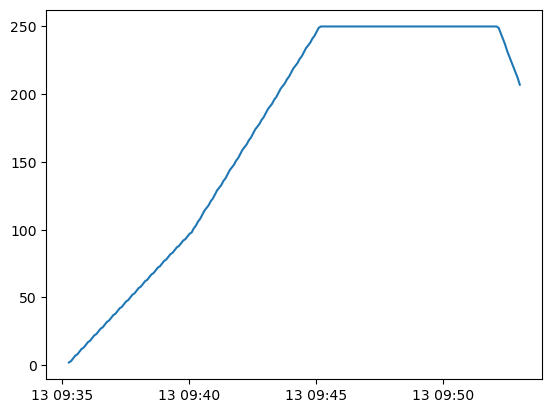

In [150]:
vus_ws_receivers = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="ws_receivers"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
plt.plot(vus_ws_receivers)
plt.show()

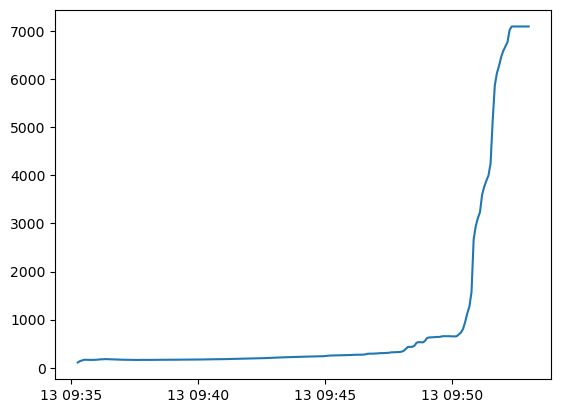

In [151]:
ws_lat = prom_query_range(
    'k6_ws_delivery_latency_ms_p95',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
plt.plot(ws_lat)
plt.show()

/var/folders/h_/g_jb8h7n13lfcr4gg3hsn8340000gn/T/ipykernel_98569/3560764885.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


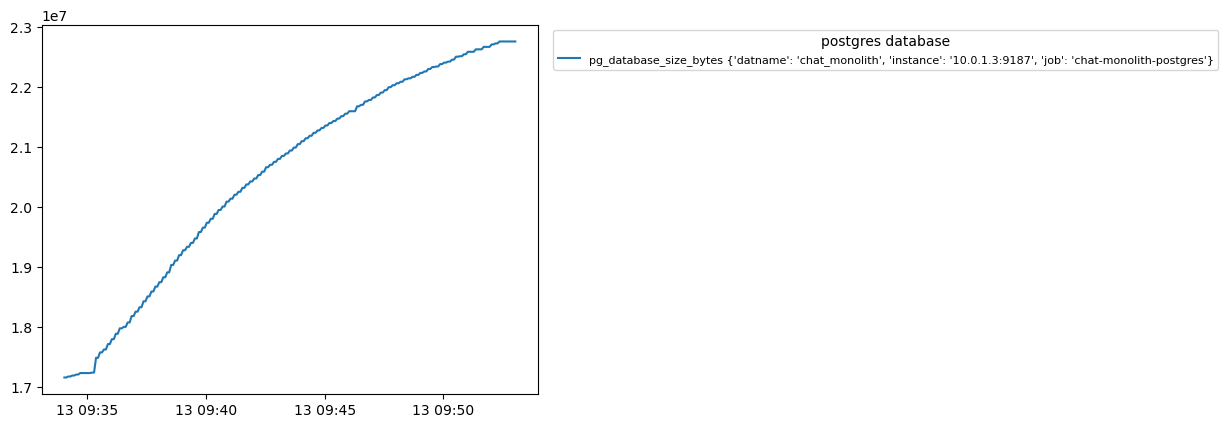

In [152]:
# Postgres logical DB size for chat_monolith
pg_database_size_chat_monolith = prom_query_range(
    'pg_database_size_bytes{datname="chat_monolith"}',
    START, END, STEP, base_url=PROMETHEUS_URL,
)

for col in pg_database_size_chat_monolith.columns:
    plt.plot(pg_database_size_chat_monolith.index, pg_database_size_chat_monolith[col], label=str(col))
plt.legend(title="postgres database", fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


/var/folders/h_/g_jb8h7n13lfcr4gg3hsn8340000gn/T/ipykernel_98569/675791614.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


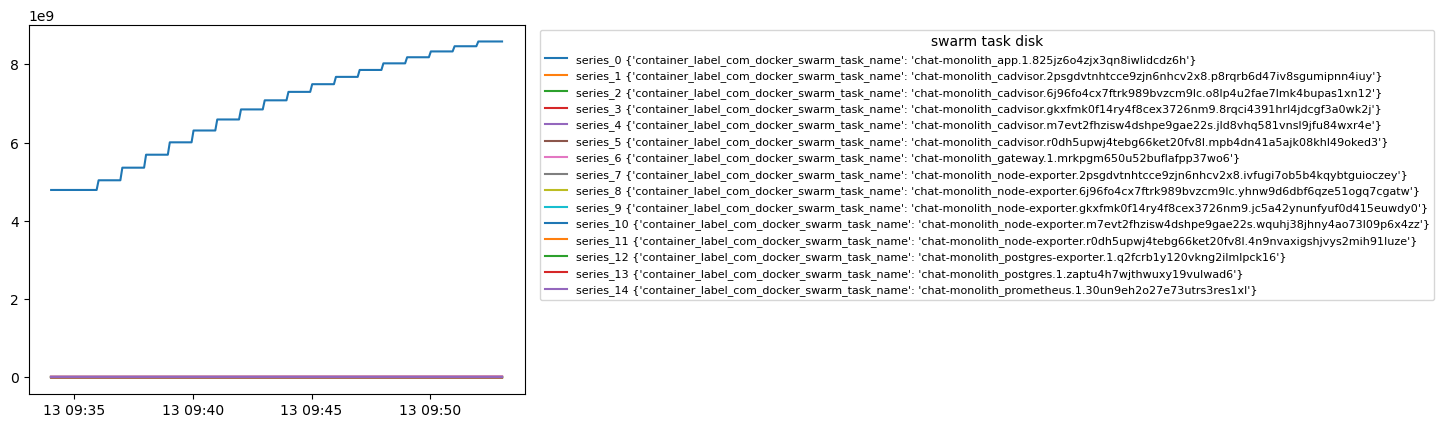

In [153]:
# Container filesystem usage per swarm task (works for app + Elasticsearch + other services)
# Use this when you want "hard disk" usage by service.
disk_by_svc = prom_query_range(
    '''sum by (container_label_com_docker_swarm_task_name) (
        container_fs_usage_bytes{
            id!="/",
            device!="",
            container_label_com_docker_swarm_service_name!=""
        }
    )''',
    START, END, STEP, base_url=PROMETHEUS_URL,
)

for col in disk_by_svc.columns:
    plt.plot(disk_by_svc.index, disk_by_svc[col], label=str(col))
plt.legend(title="swarm task disk", fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# Optional: only Elasticsearch tasks (adjust pattern if your service name differs)
es_disk = disk_by_svc.filter(regex="elasticsearch", axis=1)
if not es_disk.empty:
    ax = es_disk.plot(figsize=(10, 4), title="Elasticsearch disk usage")
    ax.set_ylabel("bytes")
    plt.tight_layout()
    plt.show()


In [154]:
from pathlib import Path
import pandas as pd


def export_data_into_one_csv(frames_to_export=[], file_name="default.csv"):
    # Build one wide table: index=timestamp, columns=all selected metric columns.
    EXPORT_DIR = Path("../exports")
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

    # frames_to_export = [
    #     "vm_cpu_pct",
    #     "java_cpu_pct",
    #     "cpu_by_svc",
    #     "java_mem",
    #     "mem_by_svc",
    #     "k6_users",
    #     "http_rt_latency",
    #     "ws_active_sessions",
    #     "ws_users",
    #     "vus_http_senders",
    #     "vus_ws_receivers",
    #     "ws_lat",
    # ]

    wide_parts = []
    for frame_name in frames_to_export:
        df = globals().get(frame_name)
        if df is None:
            continue

        part = df.copy()
        part.index = pd.to_datetime(part.index, utc=True, errors="coerce")
        part = part[~part.index.isna()]

        # Prefix columns by dataframe name to avoid collisions.
        part = part.rename(columns=lambda c: f"{frame_name}__{c}")
        wide_parts.append(part)

    if not wide_parts:
        print("No DataFrames found to export.")
    else:
        combined_wide_df = pd.concat(wide_parts, axis=1).sort_index()
        combined_wide_df.index.name = "timestamp"

        output_path = EXPORT_DIR / file_name
        combined_wide_df.to_csv(output_path, index=True)

        print(f"Shape: {combined_wide_df.shape}")
        print(f"Saved: {output_path.resolve()}")


In [155]:
# export login and user management data
# export_data_into_one_csv([
#     "cpu_by_svc",
#     "mem_by_svc",
#     "k6_users",
#     "http_rt_latency"
# ], "login_and_user_management_eda.csv")

In [156]:
# export intensive search data
# export_data_into_one_csv([
#     "cpu_by_svc",
#     "mem_by_svc",
#     "k6_users",
#     "http_rt_latency",
#     "pg_database_size_chat_monolith",
# ], "intensive_search_with_index.csv")

In [157]:
# export intensive search data
# export_data_into_one_csv([
#     "cpu_by_svc",
#     "mem_by_svc",
#     "k6_users",
#     "http_rt_latency",
#     # "pg_database_size_chat_monolith",
# ], "intensive_search_eda.csv")

In [158]:
# export intensive messaging data
# export_data_into_one_csv([
#     "cpu_by_svc",
#     "mem_by_svc",
#     "ws_active_sessions",
#     "ws_users",
#     "vus_http_senders",
#     "vus_ws_receivers",
#     "ws_lat"
# ], "intensive_messaging_monolith.csv")

Shape: (229, 35)
Saved: /Users/jakubjanak/Desktop/SIT/Bakalarka/data-analysis/exports/intensive_messaging_monolith_newest.csv
